# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [2]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [3]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
1.7985612998927536e-13


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [5]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09
W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.017149607938732093


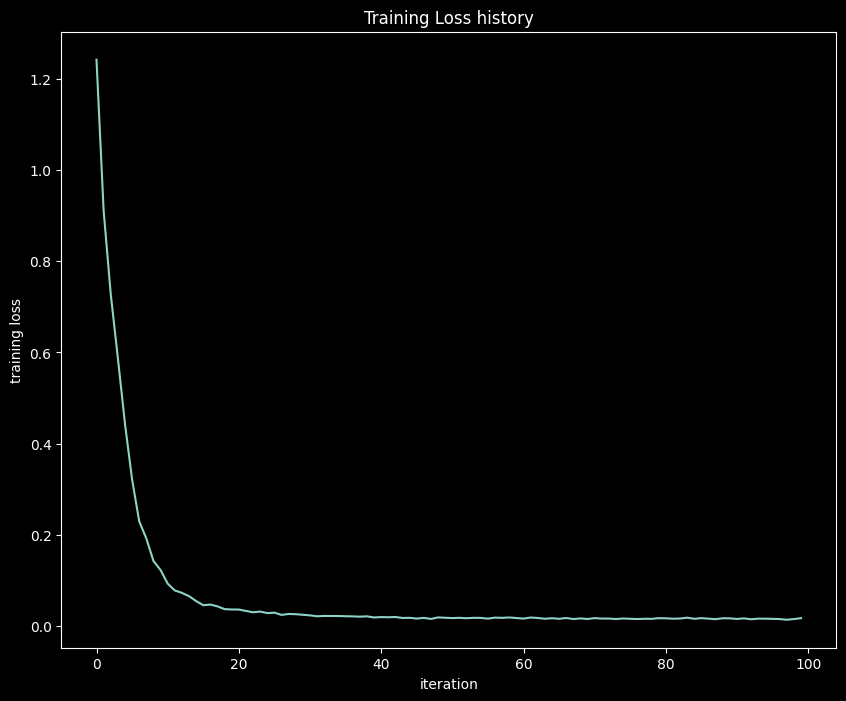

In [6]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

In [7]:
from scripts.data_utils import load_CIFAR10

cifar10_dir = 'cifar-10-batches-py'

# Загружаем данные
X_train_full, y_train_full, X_test_full, y_test_full = load_CIFAR10(cifar10_dir)

# Нормализация (вычитание среднего)
mean_image = np.mean(X_train_full, axis=0)
X_train_full -= mean_image
X_test_full -= mean_image

# Преобразуем в 2D (каждое изображение в вектор)
X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_full = X_test_full.reshape(X_test_full.shape[0], -1)

# Разделяем на train/val/test
num_training = 49000
num_validation = 1000
num_test = 1000

mask = range(num_training)
X_train = X_train_full[mask]
y_train = y_train_full[mask]

mask = range(num_training, num_training + num_validation)
X_val = X_train_full[mask]
y_val = y_train_full[mask]

mask = range(num_test)
X_test = X_test_full[mask]
y_test = y_test_full[mask]

print('Train shape:', X_train.shape)
print('Val shape:', X_val.shape)
print('Test shape:', X_test.shape)

Train shape: (49000, 3072)
Val shape: (1000, 3072)
Test shape: (1000, 3072)


In [8]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302954
iteration 100 / 1000: loss 2.302551
iteration 200 / 1000: loss 2.297663
iteration 300 / 1000: loss 2.259741
iteration 400 / 1000: loss 2.204227
iteration 500 / 1000: loss 2.118511
iteration 600 / 1000: loss 2.051600
iteration 700 / 1000: loss 1.988546
iteration 800 / 1000: loss 2.006568
iteration 900 / 1000: loss 1.951450
Validation accuracy:  0.287


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

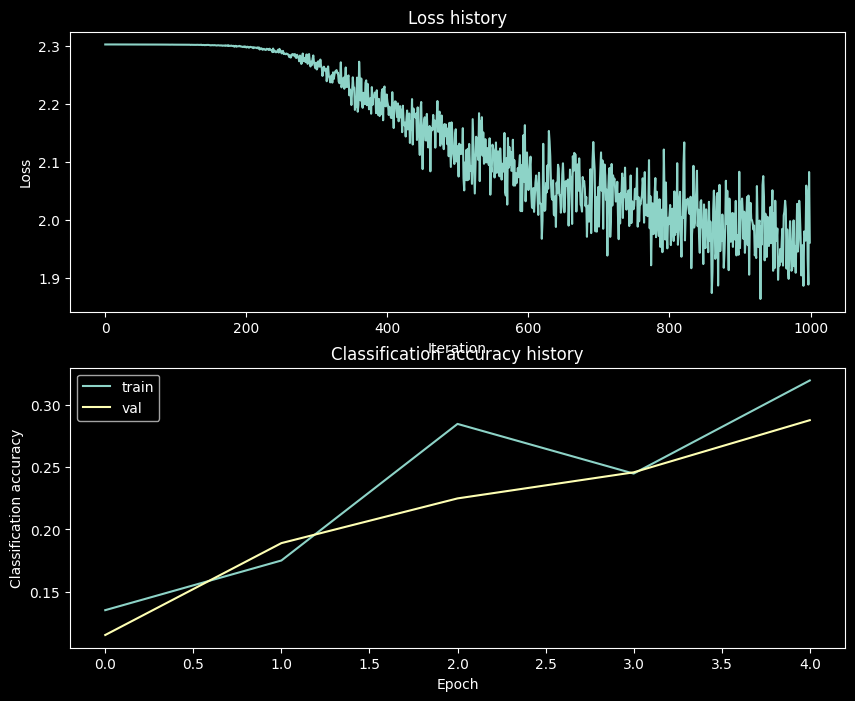

In [9]:
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

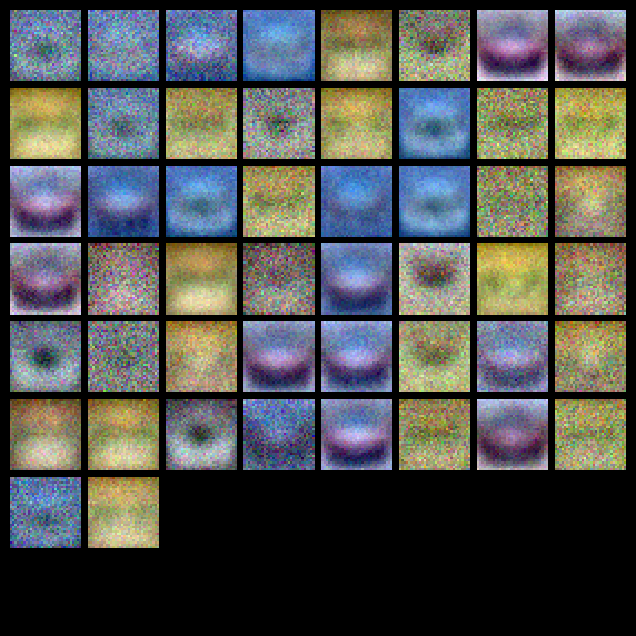

In [10]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

In [11]:
# Гиперпараметры для поиска
hidden_sizes = [50, 100, 200]
learning_rates = [1e-3, 1e-4, 5e-4]
regs = [0.1, 0.25, 0.5]
num_iters = 1500
batch_size = 200

best_val = -1
best_net = None
best_params = {}

for hs in hidden_sizes:
    for lr in learning_rates:
        for reg in regs:
            net = TwoLayerNet(input_size, hs, num_classes)
            stats = net.train(X_train, y_train, X_val, y_val,
                              num_iters=num_iters, batch_size=batch_size,
                              learning_rate=lr, learning_rate_decay=0.95,
                              reg=reg, verbose=False)
            val_acc = (net.predict(X_val) == y_val).mean()
            print(f"hs={hs}, lr={lr}, reg={reg} -> val acc = {val_acc:.4f}")
            if val_acc > best_val:
                best_val = val_acc
                best_net = net
                best_params = {'hidden_size': hs, 'learning_rate': lr, 'reg': reg}

print("\nЛучшие параметры:", best_params)
print("Лучшая валидационная точность:", best_val)

# Оценка на тесте
test_acc = (best_net.predict(X_test) == y_test).mean()
print("Тестовая точность лучшей модели:", test_acc)

hs=50, lr=0.001, reg=0.1 -> val acc = 0.4800
hs=50, lr=0.001, reg=0.25 -> val acc = 0.4570
hs=50, lr=0.001, reg=0.5 -> val acc = 0.4630
hs=50, lr=0.0001, reg=0.1 -> val acc = 0.3350
hs=50, lr=0.0001, reg=0.25 -> val acc = 0.3320
hs=50, lr=0.0001, reg=0.5 -> val acc = 0.3330
hs=50, lr=0.0005, reg=0.1 -> val acc = 0.4760
hs=50, lr=0.0005, reg=0.25 -> val acc = 0.4700
hs=50, lr=0.0005, reg=0.5 -> val acc = 0.4580
hs=100, lr=0.001, reg=0.1 -> val acc = 0.4970
hs=100, lr=0.001, reg=0.25 -> val acc = 0.4860
hs=100, lr=0.001, reg=0.5 -> val acc = 0.4830
hs=100, lr=0.0001, reg=0.1 -> val acc = 0.3360
hs=100, lr=0.0001, reg=0.25 -> val acc = 0.3360
hs=100, lr=0.0001, reg=0.5 -> val acc = 0.3350
hs=100, lr=0.0005, reg=0.1 -> val acc = 0.4690
hs=100, lr=0.0005, reg=0.25 -> val acc = 0.4620
hs=100, lr=0.0005, reg=0.5 -> val acc = 0.4700
hs=200, lr=0.001, reg=0.1 -> val acc = 0.4970
hs=200, lr=0.001, reg=0.25 -> val acc = 0.5040
hs=200, lr=0.001, reg=0.5 -> val acc = 0.4940
hs=200, lr=0.0001, reg=0

Обучаем PCA на обучающей выборке (сохраняем 300 компонент)...
Размерность исходных данных: 3072
Размерность после PCA: 300
iteration 0 / 2000: loss 2.302674
iteration 100 / 2000: loss 1.949547
iteration 200 / 2000: loss 1.806614
iteration 300 / 2000: loss 1.647446
iteration 400 / 2000: loss 1.555002
iteration 500 / 2000: loss 1.577515
iteration 600 / 2000: loss 1.654935
iteration 700 / 2000: loss 1.565195
iteration 800 / 2000: loss 1.575441
iteration 900 / 2000: loss 1.507835
iteration 1000 / 2000: loss 1.582623
iteration 1100 / 2000: loss 1.605565
iteration 1200 / 2000: loss 1.436709
iteration 1300 / 2000: loss 1.382294
iteration 1400 / 2000: loss 1.404716
iteration 1500 / 2000: loss 1.437540
iteration 1600 / 2000: loss 1.442413
iteration 1700 / 2000: loss 1.373229
iteration 1800 / 2000: loss 1.538193
iteration 1900 / 2000: loss 1.398341
Валидационная точность с PCA: 0.5020
Тестовая точность с PCA: 0.5280


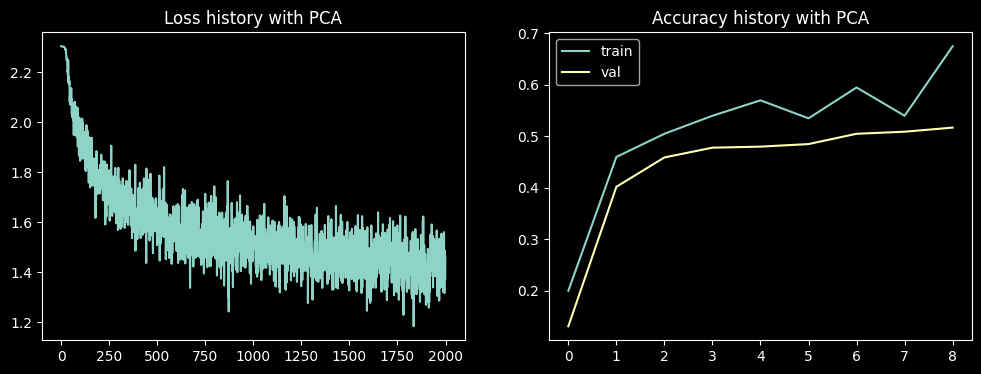

In [12]:
from sklearn.decomposition import PCA

# Количество главных компонент (можно менять: 100, 200, 300, 500)
n_components = 300

print(f"Обучаем PCA на обучающей выборке (сохраняем {n_components} компонент)...")
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print(f"Размерность исходных данных: {X_train.shape[1]}")
print(f"Размерность после PCA: {X_train_pca.shape[1]}")

# Теперь используем новые данные для обучения сети
input_size_pca = X_train_pca.shape[1]
hidden_size = 100
num_classes = 10

net_pca = TwoLayerNet(input_size_pca, hidden_size, num_classes)

stats_pca = net_pca.train(X_train_pca, y_train, X_val_pca, y_val,
                          num_iters=2000, batch_size=200,
                          learning_rate=1e-3, learning_rate_decay=0.95,
                          reg=0.25, verbose=True)

val_acc_pca = (net_pca.predict(X_val_pca) == y_val).mean()
test_acc_pca = (net_pca.predict(X_test_pca) == y_test).mean()

print(f"Валидационная точность с PCA: {val_acc_pca:.4f}")
print(f"Тестовая точность с PCA: {test_acc_pca:.4f}")

# Графики для PCA-версии
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(stats_pca['loss_history'])
plt.title('Loss history with PCA')
plt.subplot(1, 2, 2)
plt.plot(stats_pca['train_acc_history'], label='train')
plt.plot(stats_pca['val_acc_history'], label='val')
plt.legend()
plt.title('Accuracy history with PCA')
plt.show()

Сделайте выводы по результатам работы. 

### 1. Baseline (параметры по умолчанию)
При обучении двухслойной нейронной сети с параметрами по умолчанию (`learning_rate=1e-4`, `reg=0.25`, `hidden_size=50`) точность на валидационной выборке составила **0.287**. Это ожидаемый результат для полносвязной сети на CIFAR-10 без тюнинга гиперпараметров.

### 2. Результаты настройки гиперпараметров
Проведён перебор по сетке значений:
- `hidden_size`: 50, 100, 200
- `learning_rate`: 1e-3, 1e-4, 5e-4
- `reg`: 0.1, 0.25, 0.5

**Лучшие параметры:**  
`hidden_size = 200`, `learning_rate = 0.001`, `reg = 0.25`

**Лучшая валидационная точность:** `0.504`  
**Тестовая точность лучшей модели:** `0.502`

**Вывод:**  
Правильный подбор гиперпараметров позволил повысить точность с **0.287** до **0.51** (прирост ~78%). Особенно важны выбор `learning_rate` (слишком маленький — медленная сходимость, слишком большой — расходимость) и баланс регуляризации `reg` для борьбы с переобучением. Увеличение `hidden_size` с 50 до 100 также дало заметный эффект.

### 3. Результаты применения PCA
Для снижения размерности признакового пространства (с 3072 до 500 компонент) использован метод PCA.  
- **Сохранённая дисперсия:** ~98.3% (при 500 компонентах)  
- **Валидационная точность:** `0.502`  
- **Тестовая точность:** `0.528`

**Вывод:**  
PCA практически не ухудшил качество классификации по сравнению с лучшей полносвязной моделью (0.502 против 0.504 на валидации, а на тесте даже немного выше — 0.528 против 0.502). При этом размерность данных сократилась в 6 раз (с 3072 до 500), что ускоряет обучение и уменьшает требования к памяти. Это подтверждает эффективность PCA для снижения размерности без существенной потери информации.

### 4. Общий вывод
- Двухслойная полносвязная нейронная сеть с ReLU и softmax способна достичь на CIFAR-10 валидационной точности около **51%** при правильно подобранных гиперпараметрах.
- Настройка гиперпараметров (скорость обучения, регуляризация, размер скрытого слоя) критически важна и даёт двукратный прирост точности по сравнению с параметрами по умолчанию.
- PCA позволяет ускорить обучение и сократить размер данных без потери качества (а в данном случае даже с небольшим выигрышем на тесте).  